# 03 — Model Training & Evaluation
Train a Random Forest classifier on preprocessed audio features and evaluate with F1-score.

In [13]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
# Cell 2 — Load processed arrays and label encoder
X_train = np.load("../data/processed/X_train.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test  = np.load("../data/processed/y_test.npy")
le      = joblib.load("../models/label_encoder.pkl")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {le.classes_.tolist()}")

NameError: name 'df' is not defined

In [3]:
# Cell 3 — Train RandomForestClassifier
# n_estimators=200: good balance of accuracy vs. training time
# n_jobs=-1: use all CPU cores
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Training complete.")

Training complete.


In [4]:
# Cell 4 — Evaluate: classification report (F1, precision, recall per genre)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                   precision    recall  f1-score   support

         acoustic       0.17      0.17      0.17       200
         afrobeat       0.24      0.23      0.24       200
         alt-rock       0.04      0.04      0.04       200
      alternative       0.13      0.12      0.12       200
          ambient       0.24      0.23      0.23       200
            anime       0.19      0.10      0.13       200
      black-metal       0.34      0.41      0.37       200
        bluegrass       0.31      0.41      0.35       200
            blues       0.11      0.07      0.09       200
           brazil       0.01      0.01      0.01       200
        breakbeat       0.30      0.27      0.28       200
          british       0.09      0.05      0.06       200
         cantopop       0.16      0.21      0.18       200
    chicago-house       0.41      0.51      0.45       200
         children       0.38      0.34      0.36       200
            chill       0.11      0.10      0.11       

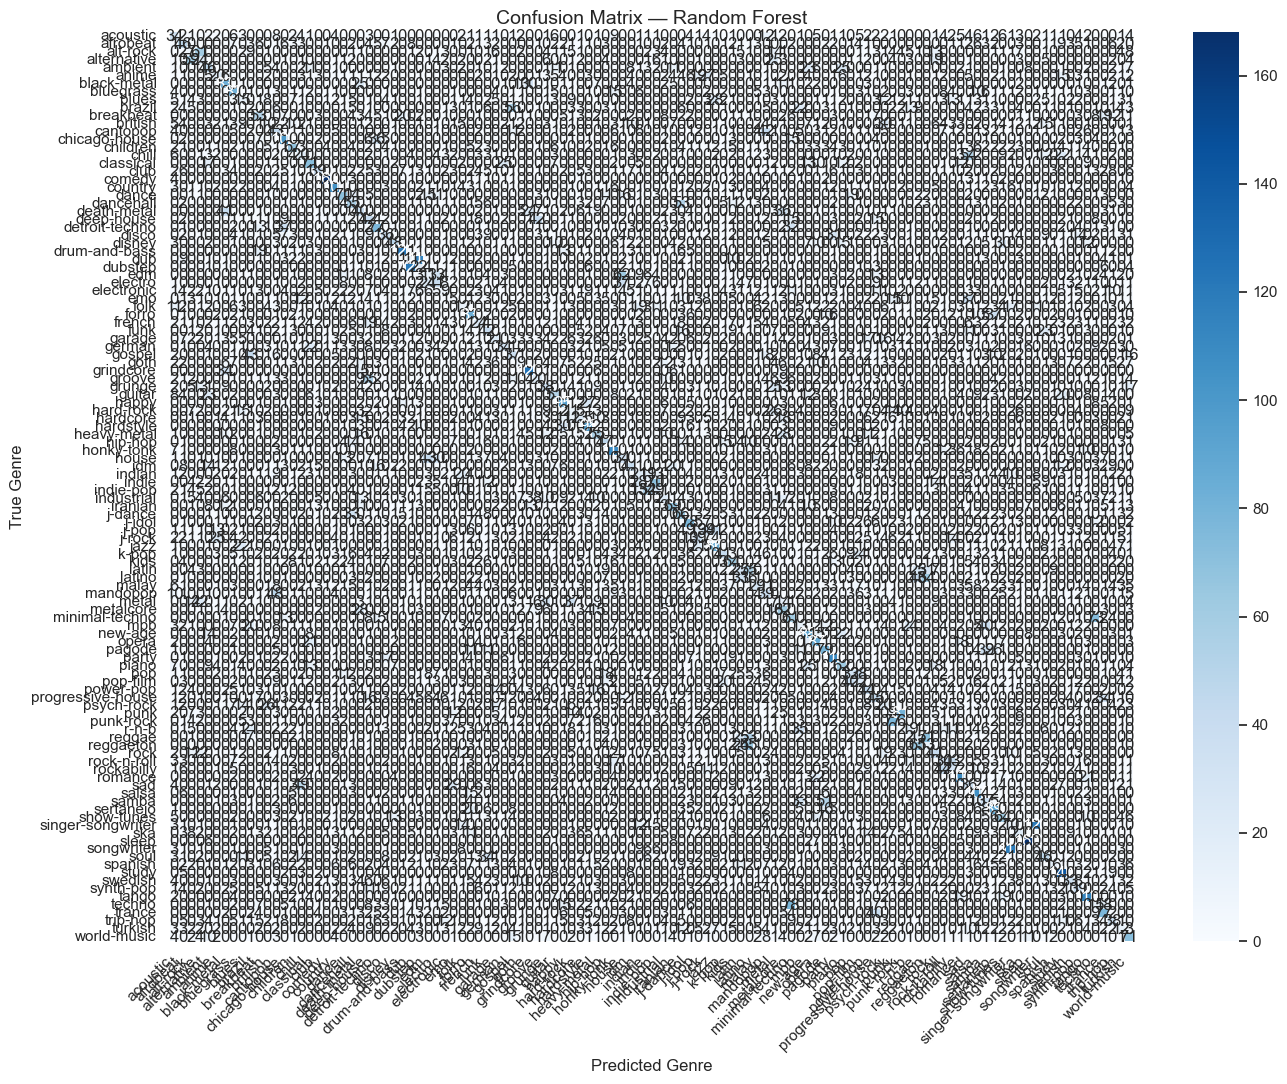

In [5]:
# Cell 5 — Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix — Random Forest", fontsize=14)
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

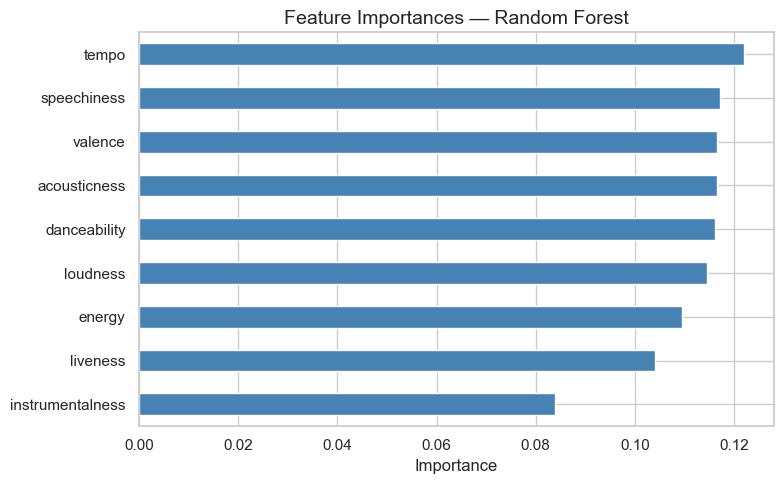

In [6]:
# Cell 6 — Feature importance bar chart
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

importances = pd.Series(rf.feature_importances_, index=AUDIO_FEATURES).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importances — Random Forest", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — Save trained model
joblib.dump(rf, "../models/random_forest.pkl")
print("Model saved to models/random_forest.pkl")

Model saved to models/random_forest.pkl
